<a href="https://colab.research.google.com/github/Askaaarrr/NUSIF-PM-work/blob/main/portfolio_analytics_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Quant Portfolio Toolkit — v2

Educational and research toolkit for quantitative portfolio analysis: from quote loading to option valuation. Each block contains a short explanation of **what we are calculating** and **how to interpret the result**.

**Notebook Logic (step-by-step):**
1. Define the portfolio (tickers + number of shares).
2. Load prices (file or `yfinance`), fix a unified asset order.
3. Calculate returns, covariance (including Ledoit–Wolf shrinkage), correlations.
4. Assess risk: volatility and each asset's contribution (Euler decomposition).
5. Optimize weights: GMV, Max-Sharpe (tangent), Risk-Parity.
6. Summary table of metrics + efficient frontier with CML.
7. Tail risk: VaR and CVaR (3 methods).
8. Fama–French factor model (real factors) with robust errors.
9. Black–Scholes–Merton option pricing: price, Greeks, put-call parity.

> Units: daily prices → all annual metrics are scaled by `TRADING_DAYS = 252`.

## 1. Environment Setup

Run this block first. It imports libraries and sets global constants (risk-free rate, number of trading days, generator seed for reproducibility).

In [19]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import norm, skew, kurtosis
from sklearn.covariance import LedoitWolf

# --- Global Settings ---
TRADING_DAYS = 252          # trading days per year (daily data)
RF_ANNUAL    = 0.04         # annual risk-free rate (for Sharpe / tangent portfolio)
RF_DAILY     = RF_ANNUAL / TRADING_DAYS
CONF         = 0.95         # confidence level for VaR / CVaR
SEED         = 42
rng = np.random.default_rng(SEED)

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
print("Environment ready. RF_ANNUAL =", RF_ANNUAL, "| TRADING_DAYS =", TRADING_DAYS)

Environment ready. RF_ANNUAL = 0.04 | TRADING_DAYS = 252


## 2. Portfolio Composition

Tickers and number of shares. Market weights are calculated automatically from here later.

In [20]:
holdings = {
    "ASML": 1, "META": 2, "TTWO": 4, "VTIP": 18, "SCHO": 37, "PG": 6, "MMM": 4,
    "COP": 5, "UL": 8, "SPOT": 1, "VCSH": 6, "NEE": 5, "AVGO": 1, "MLI": 4,
}
quantities = pd.Series(holdings, name="Quantity")
print("Portfolio has", len(holdings), "positions.")

Portfolio has 14 positions.


## 3. Data Loading

Two ways:
- **A. Your own file** — `load_prices_from_file` function (csv / xlsx / dta / parquet). Expects a table: first column — dates, others — asset prices.
- **B. Live data** — via `yfinance`.

**Important:** Immediately after loading, fix a unified asset order `ASSETS = list(prices.columns)` and reindex `quantities` to it. This eliminates a major hidden error — desynchronization of ticker order between weights and covariance.

In [21]:
def load_prices_from_file(path):
    """Universal price loader. Returns a DataFrame with DatetimeIndex."""
    if path.endswith(".csv"):
        df = pd.read_csv(path, index_col=0, parse_dates=True)
    elif path.endswith((".xlsx", ".xls")):
        df = pd.read_excel(path, index_col=0, parse_dates=True)
    elif path.endswith(".dta"):
        df = pd.read_stata(path)
    elif path.endswith(".parquet"):
        df = pd.read_parquet(path)
    else:
        raise ValueError("Supported formats are .csv, .xlsx, .dta, .parquet")
    return df.sort_index().apply(pd.to_numeric, errors="coerce")

# Example: prices = load_prices_from_file("my_prices.csv")

In [22]:
# --- Option B: Live data via yfinance ---
try:
    import yfinance as yf
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "yfinance", "-q"])
    import yfinance as yf

START_DATE = "2021-01-01"
raw = yf.download(list(holdings.keys()), start=START_DATE, auto_adjust=True, progress=False)

# yfinance might return MultiIndex columns: take adjusted close prices
if isinstance(raw.columns, pd.MultiIndex):
    field = "Adj Close" if "Adj Close" in raw.columns.get_level_values(0) else "Close"
    prices = raw[field].copy()
else:
    prices = raw.copy()

prices = prices.dropna(how="all").ffill().dropna()

# --- UNIFIED asset order for the entire notebook ---
ASSETS = list(prices.columns)
quantities = quantities.reindex(ASSETS)
n = len(ASSETS)

print(f"Loaded {n} assets, {len(prices)} trading days "
      f"({prices.index.min().date()} — {prices.index.max().date()}).")
display(prices.tail())

Loaded 14 assets, 1400 trading days (2021-01-04 — 2026-07-31).


Ticker,ASML,AVGO,COP,META,MLI,MMM,NEE,PG,SCHO,SPOT,TTWO,UL,VCSH,VTIP
Date,,,,,,,,,,,,,,
2026-07-27,1653.122070,383.220001,115.580002,593.869995,64.169998,178.229996,88.830002,148.630005,24.059999,494.720001,243.949997,61.369999,78.500000,49.52
2026-07-28,1582.949951,380.910004,114.099998,593.409973,66.489998,182.479996,89.279999,148.880005,24.080000,511.559998,247.619995,66.870003,78.620003,49.57
2026-07-29,1550.689941,370.320007,118.059998,585.609985,65.400002,177.949997,88.459999,146.100006,24.090000,524.010010,246.429993,66.000000,78.610001,49.68
2026-07-30,1651.439941,387.839996,119.029999,539.030029,66.860001,176.070007,87.930000,143.960007,24.110001,522.609985,247.429993,65.269997,78.669998,49.66
2026-07-31,1629.000000,389.279999,120.480003,556.710022,66.410004,176.279999,86.919998,144.490005,24.100000,499.940002,242.919998,63.410000,78.620003,49.66


## 4. Portfolio Market Weights

Current market value of a position = last price × quantity. Weight = position value / portfolio value. All weight vectors are strictly in `ASSETS` order.

In [23]:
last_price   = prices.iloc[-1].reindex(ASSETS)
market_value = (last_price * quantities).rename("Market Value")
w_actual     = (market_value / market_value.sum()).reindex(ASSETS).values   # actual weights
w_eq         = np.ones(n) / n                                                # equal weights

book = pd.DataFrame({"Quantity": quantities, "Last Price": last_price.round(2),
                     "Market Value": market_value.round(2),
                     "Weight %": (w_actual * 100).round(2)}, index=ASSETS)
print("Portfolio Value: {:,.2f}".format(market_value.sum()))
display(book.sort_values("Weight %", ascending=False))

Portfolio Value: 10,242.60


,Quantity,Last Price,Market Value,Weight %
ASML,1,1629.00,1629.00,15.90
META,2,556.71,1113.42,10.87
TTWO,4,242.92,971.68,9.49
VTIP,18,49.66,893.88,8.73
SCHO,37,24.10,891.70,8.71
PG,6,144.49,866.94,8.46
MMM,4,176.28,705.12,6.88
COP,5,120.48,602.40,5.88
UL,8,63.41,507.28,4.95
SPOT,1,499.94,499.94,4.88


## 5. Returns

Transition from prices to simple daily returns `r_t = P_t / P_{t-1} − 1`. Simple (not logarithmic) returns are chosen because portfolio return = weighted sum of asset returns only for simple returns.

**How to read:** a value of `0.012` = asset increased by 1.2% in a day. The first row is removed (no previous price).

In [24]:
returns = prices.pct_change().dropna()
print("Returns matrix:", returns.shape)
display(returns.tail().round(4))

Returns matrix: (1399, 14)


Ticker,ASML,AVGO,COP,META,MLI,MMM,NEE,PG,SCHO,SPOT,TTWO,UL,VCSH,VTIP
Date,,,,,,,,,,,,,,
2026-07-27,-0.0580,0.0034,-0.0389,-0.0022,0.0041,0.0325,-0.0106,0.0083,0.0000,0.0250,0.0531,0.0071,0.0004,-0.0014
2026-07-28,-0.0424,-0.0060,-0.0128,-0.0008,0.0362,0.0238,0.0051,0.0017,0.0008,0.0340,0.0150,0.0896,0.0015,0.0010
2026-07-29,-0.0204,-0.0278,0.0347,-0.0131,-0.0164,-0.0248,-0.0092,-0.0187,0.0004,0.0243,-0.0048,-0.0130,-0.0001,0.0022
2026-07-30,0.0650,0.0473,0.0082,-0.0795,0.0223,-0.0106,-0.0060,-0.0146,0.0008,-0.0027,0.0041,-0.0111,0.0008,-0.0004
2026-07-31,-0.0136,0.0037,0.0122,0.0328,-0.0067,0.0012,-0.0115,0.0037,-0.0004,-0.0434,-0.0182,-0.0285,-0.0006,0.0000


## 6. Covariance, Shrinkage, and Correlations

- **Sample cov** — ordinary sample covariance.
- **Ledoit–Wolf shrinkage** — "shrunk" covariance: pulls the sample matrix towards a structured target. On short samples, it is more stable when inverted (important for GMV/tangent portfolio, where `Σ⁻¹` is needed). This is what we use in optimization.

**How to read correlation:** `+1` — move synchronously, `0` — independent, `<0` — in antiphase (better diversification).

In [25]:
mu       = returns.mean().values                 # mean daily return (vector)
Sigma_s  = returns.cov().values                  # sample covariance
lw       = LedoitWolf().fit(returns.values)
Sigma    = lw.covariance_                         # shrunk covariance (working)
corr     = returns.corr()

print(f"Ledoit–Wolf shrinkage intensity: {lw.shrinkage_:.3f}  (0 = pure sample, 1 = pure target)")
display(corr.round(2))

Ledoit–Wolf shrinkage intensity: 0.017  (0 = pure sample, 1 = pure target)


Ticker,ASML,AVGO,COP,META,MLI,MMM,NEE,PG,SCHO,SPOT,TTWO,UL,VCSH,VTIP
Ticker,,,,,,,,,,,,,,
ASML,1.00,0.62,0.15,0.44,0.40,0.27,0.18,0.06,0.02,0.37,0.30,0.10,0.23,0.09
AVGO,0.62,1.00,0.13,0.40,0.32,0.22,0.11,-0.01,-0.02,0.33,0.27,0.03,0.17,0.06
COP,0.15,0.13,1.00,0.07,0.28,0.20,0.11,0.02,-0.15,0.08,0.09,0.01,-0.00,0.14
META,0.44,0.40,0.07,1.00,0.23,0.25,0.13,0.10,-0.01,0.45,0.31,0.10,0.18,0.05
MLI,0.40,0.32,0.28,0.23,1.00,0.39,0.18,0.12,-0.02,0.22,0.21,0.12,0.16,0.07
MMM,0.27,0.22,0.20,0.25,0.39,1.00,0.23,0.27,0.03,0.15,0.15,0.26,0.19,0.06
NEE,0.18,0.11,0.11,0.13,0.18,0.23,1.00,0.38,0.18,0.16,0.16,0.24,0.30,0.21
PG,0.06,-0.01,0.02,0.10,0.12,0.27,0.38,1.00,0.15,0.02,0.06,0.51,0.22,0.11
SCHO,0.02,-0.02,-0.15,-0.01,-0.02,0.03,0.18,0.15,1.00,0.07,0.02,0.16,0.81,0.68


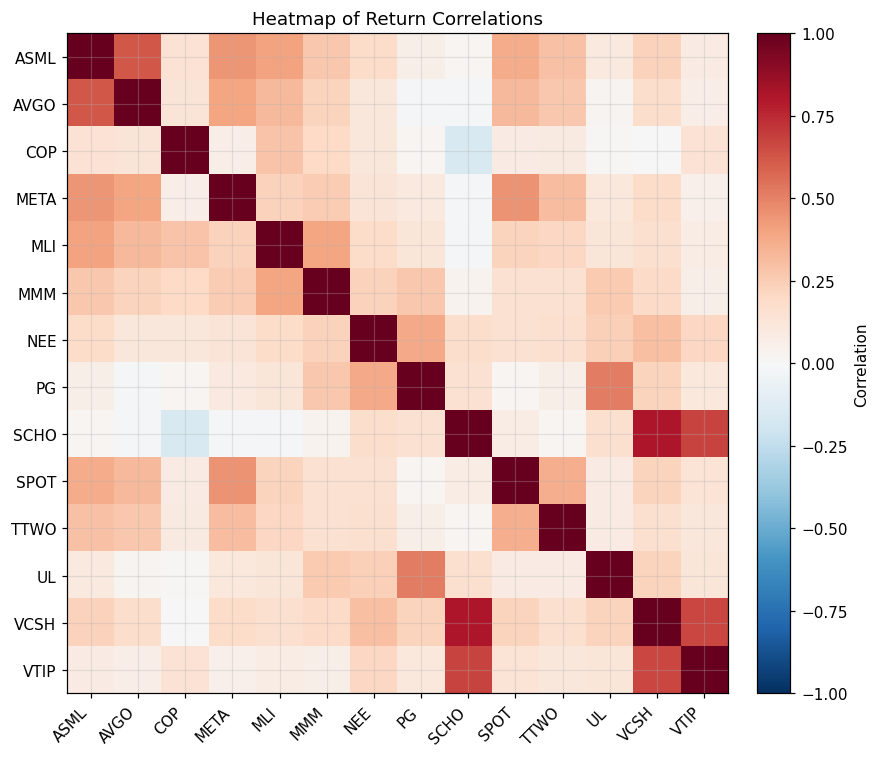

In [26]:
# Heatmap of correlations (vectorized, without annotations for readability 14x14)
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(n)); ax.set_xticklabels(ASSETS, rotation=45, ha="right")
ax.set_yticks(range(n)); ax.set_yticklabels(ASSETS)
fig.colorbar(im, label="Correlation", fraction=0.046, pad=0.04)
ax.set_title("Heatmap of Return Correlations")
plt.tight_layout(); plt.show()

## 7. Basic Risk Functions

Portfolio volatility: `σ_p = √(wᵀ Σ w)`. Below is a set of functions reused throughout the notebook. We calculate volatility for actual and equal weights (annualized).

In [27]:
def port_return_daily(w):
    """Expected daily portfolio return."""
    return float(np.asarray(w) @ mu)

def port_vol_daily(w, S=Sigma):
    """Daily portfolio volatility."""
    w = np.asarray(w)
    return float(np.sqrt(w @ S @ w))

def annualize_return(r_daily):
    return (1 + r_daily) ** TRADING_DAYS - 1

def annualize_vol(v_daily):
    return v_daily * np.sqrt(TRADING_DAYS)

def risk_contributions(w, S=Sigma):
    """Euler decomposition: absolute and percentage contribution of each asset to σ_p."""
    w   = np.asarray(w)
    s   = np.sqrt(w @ S @ w)
    mcr = (S @ w) / s          # marginal contribution
    ccr = w * mcr              # component (absolute) contribution, Σ ccr = σ_p
    return ccr, ccr / s        # (absolute, percentage)

print(f"Annualized volatility — actual weights: {annualize_vol(port_vol_daily(w_actual)):.2%}")
print(f"Annualized volatility — equal weights:      {annualize_vol(port_vol_daily(w_eq)):.2%}")

Annualized volatility — actual weights: 16.12%
Annualized volatility — equal weights:      14.66%


## 8. Risk Contribution (Euler Decomposition)

Shows which asset genuinely creates risk — regardless of its monetary share.

**How to read:** if an asset's weight is 8%, but its risk contribution is 20% — the asset disproportionately drives portfolio volatility.

In [28]:
_, pct_actual = risk_contributions(w_actual)
rc = pd.DataFrame({"Weight %": (w_actual * 100).round(2),
                   "Risk Contribution %": (pct_actual * 100).round(2)}, index=ASSETS)
display(rc.sort_values("Risk Contribution %", ascending=False))

,Weight %,Risk Contribution %
ASML,15.90,34.50
META,10.87,20.79
TTWO,9.49,10.36
SPOT,4.88,8.55
AVGO,3.80,6.43
MMM,6.88,5.69
COP,5.88,3.54
MLI,2.59,2.68
PG,8.46,2.49
NEE,4.24,2.49


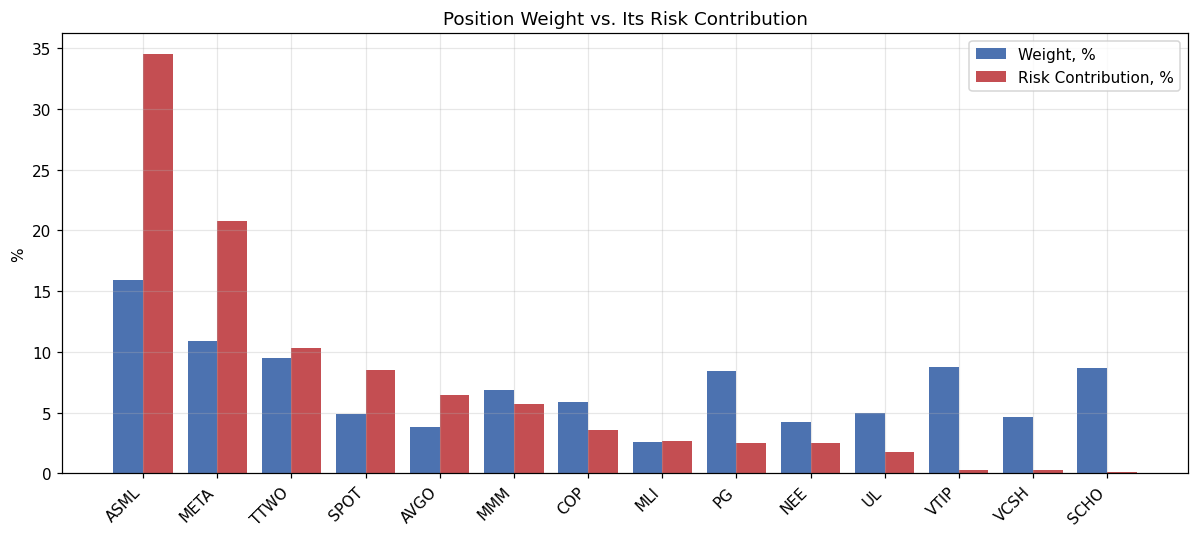

In [29]:
x = np.arange(n)
order = np.argsort(-pct_actual)
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - 0.2, w_actual[order] * 100,   width=0.4, label="Weight, %",         color="#4C72B0")
ax.bar(x + 0.2, pct_actual[order] * 100, width=0.4, label="Risk Contribution, %", color="#C44E52")
ax.set_xticks(x); ax.set_xticklabels(np.array(ASSETS)[order], rotation=45, ha="right")
ax.set_ylabel("%"); ax.set_title("Position Weight vs. Its Risk Contribution")
ax.legend(); plt.tight_layout(); plt.show()

## 9. Weight Optimization

Three classical strategies:
1. **GMV** — global minimum variance (minimum risk).
2. **Max-Sharpe (tangent)** — maximum (return − rf) / risk ratio.
3. **Risk-Parity (ERC)** — weights such that each asset contributes equally to risk.

For each, we provide an **analytical** solution (fast, allows shorts) and a **long-only** numerical one (weights ≥ 0, sum = 1). We invert the shrunk `Σ` — it's more stable.

Risk-Parity is solved in a canonical convex form (Spinu / Maillard–Roncalli): `min 0.5·wᵀΣw − (1/n)·Σ log(wᵢ)`, then normalized — this gives exactly equal contributions.

In [30]:
inv  = np.linalg.inv(Sigma)
ones = np.ones(n)

# --- Analytical solutions (allow short positions) ---
w_gmv_cf = inv @ ones / (ones @ inv @ ones)
excess   = mu - RF_DAILY
w_tan_cf = inv @ excess / (ones @ inv @ excess)

# --- Constraints for long-only ---
def _sum_to_one(w):
    return w.sum() - 1.0

CONS  = ({"type": "eq", "fun": _sum_to_one},)
BNDS  = [(0.0, 1.0)] * n

# GMV long-only
def _obj_variance(w):
    return port_vol_daily(w) ** 2

w_gmv = minimize(_obj_variance, w_eq, method="SLSQP",
                 bounds=BNDS, constraints=CONS).x

# Max-Sharpe long-only
def _neg_sharpe(w):
    return -(port_return_daily(w) - RF_DAILY) / port_vol_daily(w)

w_tan = minimize(_neg_sharpe, w_eq, method="SLSQP",
                 bounds=BNDS, constraints=CONS).x

# Risk-Parity (ERC) via log-barrier
b = np.ones(n) / n
def _erc_obj(w):
    return 0.5 * (w @ Sigma @ w) - b @ np.log(w)
def _erc_grad(w):
    return Sigma @ w - b / w

sol  = minimize(_erc_obj, w_eq, jac=_erc_grad, method="L-BFGS-B",
                bounds=[(1e-12, None)] * n, options={"maxiter": 10000, "ftol": 1e-16})
w_rp = sol.x / sol.x.sum()

weights_tbl = pd.DataFrame({
    "GMV (long-only)":   w_gmv,
    "Max-Sharpe":        w_tan,
    "Risk-Parity":       w_rp,
    "Actual":           w_actual,
}, index=ASSETS)
display((weights_tbl * 100).round(2))

,GMV (long-only),Max-Sharpe,Risk-Parity,Actual
ASML,7.14,0.00,1.60,15.90
AVGO,7.14,32.45,1.85,3.80
COP,7.14,23.07,3.32,5.88
META,7.14,0.00,1.78,10.87
MLI,7.14,44.48,2.28,2.59
MMM,7.14,0.00,2.73,6.88
NEE,7.14,0.00,3.00,4.24
PG,7.14,0.00,5.04,8.46
SCHO,7.14,0.00,28.30,8.71
SPOT,7.14,0.00,1.65,4.88


## 10. Summary Table of Metrics

For each set of weights, we calculate annual metrics:
- **CAGR** — compound annual growth rate, **Vol** — annual volatility.
- **Sharpe** = (return − rf) / vol; **Sortino** — same, but denominator uses only "bad" volatility.
- **MaxDD** — maximum drawdown.
- **VaR/CVaR (95%)** — daily tail risk (see block 12).

In [31]:
def portfolio_stats(w, name):
    w  = np.asarray(w)
    pr = returns.values @ w                     # time series of portfolio returns
    ann_r = annualize_return(pr.mean())
    ann_v = annualize_vol(pr.std(ddof=1))
    down  = pr[pr < 0].std(ddof=1) * np.sqrt(TRADING_DAYS)
    sharpe  = (ann_r - RF_ANNUAL) / ann_v
    sortino = (ann_r - RF_ANNUAL) / down
    cum = np.cumprod(1 + pr)
    mdd = (cum / np.maximum.accumulate(cum) - 1).min()
    q   = np.percentile(pr, 100 * (1 - CONF))
    var95  = -q
    cvar95 = -pr[pr <= q].mean()
    return pd.Series({"CAGR": ann_r, "Vol": ann_v, "Sharpe": sharpe, "Sortino": sortino,
                      "MaxDD": mdd, "VaR95": var95, "CVaR95": cvar95}, name=name)

summary = pd.concat([
    portfolio_stats(w_eq,     "Equal Weights"),
    portfolio_stats(w_actual, "Actual"),
    portfolio_stats(w_gmv,    "GMV"),
    portfolio_stats(w_tan,    "Max-Sharpe"),
    portfolio_stats(w_rp,     "Risk-Parity"),
], axis=1).T

pct_cols = ["CAGR", "Vol", "MaxDD", "VaR95", "CVaR95"]
fmt = summary.copy()
fmt[pct_cols] = (summary[pct_cols] * 100).round(2).astype(str) + "%"   # percentages
fmt[["Sharpe", "Sortino"]] = summary[["Sharpe", "Sortino"]].round(2)
display(fmt)

,CAGR,Vol,Sharpe,Sortino,MaxDD,VaR95,CVaR95
Equal Weights,18.95%,14.75%,1.01,1.50,-23.98%,1.4%,2.03%
Actual,17.79%,16.22%,0.85,1.26,-28.98%,1.53%,2.25%
GMV,18.95%,14.75%,1.01,1.50,-23.98%,1.4%,2.03%
Max-Sharpe,52.97%,26.28%,1.86,2.89,-23.57%,2.34%,3.48%
Risk-Parity,7.3%,5.3%,0.62,0.90,-10.45%,0.5%,0.74%


## 11. Efficient Frontier and CML

- **Blue curve** — analytical Markowitz efficient frontier (Merton, 1972): best risk for each return level.
- **Point cloud** — 5000 random long-only portfolios, color = Sharpe.
- **Line (CML)** — capital market line from the risk-free rate through the tangent portfolio; its slope = maximum Sharpe.
- Individual assets, GMV, and tangent portfolio are marked.

Annual axes.

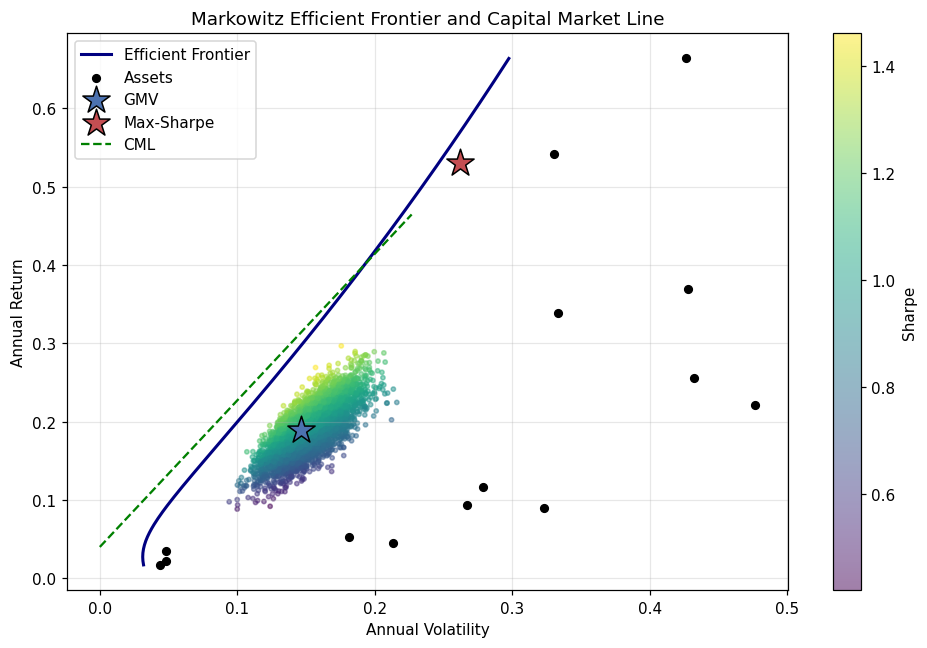

In [32]:
# --- Analytical frontier (in daily units), then annual conversion ---
A = ones @ inv @ ones
B = ones @ inv @ mu
C = mu   @ inv @ mu
D = A * C - B**2

m_grid  = np.linspace(mu.min(), mu.max(), 200)
s_grid  = np.sqrt((A * m_grid**2 - 2 * B * m_grid + C) / D)
m_grid_a = annualize_return(m_grid)
s_grid_a = annualize_vol(s_grid)

# --- Cloud of random long-only portfolios (vectorized, no loops) ---
N_SIM = 5000
W = rng.random((N_SIM, n))
W = W / W.sum(axis=1, keepdims=True)
cloud_r = annualize_return(W @ mu)
cloud_v = annualize_vol(np.sqrt(np.einsum("ij,jk,ik->i", W, Sigma, W)))
cloud_sharpe = (cloud_r - RF_ANNUAL) / cloud_v

# --- Key points ---
asset_v = annualize_vol(np.sqrt(np.diag(Sigma)))
asset_r = annualize_return(mu)
gmv_pt  = (annualize_vol(port_vol_daily(w_gmv)),  annualize_return(port_return_daily(w_gmv)))
tan_pt  = (annualize_vol(port_vol_daily(w_tan)),  annualize_return(port_return_daily(w_tan)))

fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(cloud_v, cloud_r, c=cloud_sharpe, cmap="viridis", s=8, alpha=0.5)
fig.colorbar(sc, label="Sharpe")
ax.plot(s_grid_a, m_grid_a, color="navy", lw=2, label="Efficient Frontier")
ax.scatter(asset_v, asset_r, marker="o", color="black", s=25, label="Assets")
ax.scatter(*gmv_pt, marker="*", s=350, color="#4C72B0", edgecolor="k", label="GMV", zorder=5)
ax.scatter(*tan_pt, marker="*", s=350, color="#C44E52", edgecolor="k", label="Max-Sharpe", zorder=5)

# Capital Market Line (CML)
x_cml = np.linspace(0, cloud_v.max() * 1.05, 50)
slope = (tan_pt[1] - RF_ANNUAL) / tan_pt[0]
ax.plot(x_cml, RF_ANNUAL + slope * x_cml, "--", color="green", label="CML")

ax.set_xlabel("Annual Volatility"); ax.set_ylabel("Annual Return")
ax.set_title("Markowitz Efficient Frontier and Capital Market Line")
ax.legend(loc="best"); plt.tight_layout(); plt.show()

## 12. VaR and CVaR (Tail Risk)

**VaR (95%)** — the loss that will not be exceeded with 95% probability over one day. **CVaR** — average loss in the worst 5% of cases (always ≥ VaR, better describes the tail).

Three estimates:
- **Historical** — based on empirical distribution.
- **Parametric (Normal)** — using formula with μ and σ.
- **Cornish–Fisher** — adjustment for skewness and "fat tails" (usually more accurate for real returns).

Scale to horizon `h` days ≈ `× √h` (square root of time rule).

Daily VaR 95% — historical : 0.0153
Daily VaR 95% — normal   : 0.0162
Daily VaR 95% — Cornish–Fisher: 0.0145
Daily CVaR 95% — historical: 0.0225
VaR for 5 days (√t from hist.): 0.0341


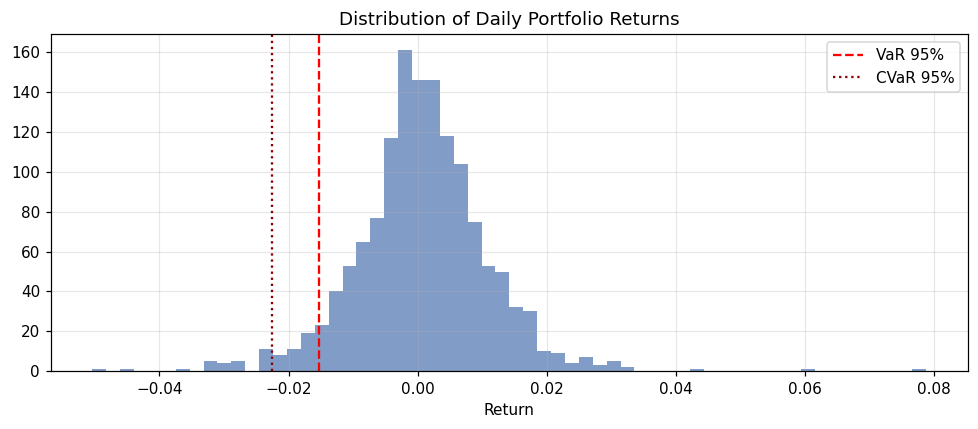

In [33]:
pr = returns.values @ w_actual
a  = 1 - CONF
z  = norm.ppf(a)
mu_p, sd_p = pr.mean(), pr.std(ddof=1)
S, K = skew(pr), kurtosis(pr, fisher=True)   # skewness and excess kurtosis

# Cornish–Fisher quantile
z_cf = z + (z**2 - 1) * S / 6 + (z**3 - 3*z) * K / 24 - (2*z**3 - 5*z) * S**2 / 36

q_hist   = np.percentile(pr, 100 * a)
var_hist = -q_hist
var_norm = -(mu_p + z * sd_p)
var_cf   = -(mu_p + z_cf * sd_p)
cvar_hist = -pr[pr <= q_hist].mean()

HORIZON = 5   # e.g., weekly horizon
print(f"Daily VaR 95% — historical : {var_hist:.4f}")
print(f"Daily VaR 95% — normal   : {var_norm:.4f}")
print(f"Daily VaR 95% — Cornish–Fisher: {var_cf:.4f}")
print(f"Daily CVaR 95% — historical: {cvar_hist:.4f}")
print(f"VaR for {HORIZON} days (√t from hist.): {var_hist * np.sqrt(HORIZON):.4f}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(pr, bins=60, color="#4C72B0", alpha=0.7)
ax.axvline(-var_hist, color="red",   ls="--", label="VaR 95%")
ax.axvline(-cvar_hist, color="darkred", ls=":", label="CVaR 95%")
ax.set_title("Distribution of Daily Portfolio Returns"); ax.set_xlabel("Return")
ax.legend(); plt.tight_layout(); plt.show()

## 13. Fama–French Factor Model (3 Factors)

Explains the source of asset returns: market (**Mkt-RF**), size (**SMB**), value (**HML**).

We use **real** factors from Ken French's library (`pandas_datareader`). We regress the excess return of the selected asset on the factors with **Newey–West robust errors (HAC)**.

**How to read:** `const` (α) — return beyond the factor model ("skill"); `Mkt-RF ≈ 1` — asset moves with the market; SMB/HML signs indicate bias towards small/value companies. Look at `t` and `P>|t|` for significance.

In [34]:
import statsmodels.api as sm
TARGET = "ASML"   # which asset to analyze

def load_ff3_daily(index):
    """Real Fama–French factors (daily). Returns DataFrame in fractions."""
    from pandas_datareader.data import DataReader
    ff = DataReader("F-F_Research_Data_Factors_daily", "famafrench",
                    start=index.min(), end=index.max())[0] / 100.0
    ff.index = pd.to_datetime(ff.index)
    return ff

try:
    ff = load_ff3_daily(returns.index)
    df = returns[[TARGET]].join(ff, how="inner").dropna()
    y  = df[TARGET] - df["RF"]
    X  = sm.add_constant(df[["Mkt-RF", "SMB", "HML"]])
    factor_source = "Real Fama–French Factors (Kenneth French Data Library)"
except Exception as e:
    # Fallback: CAPM with market proxy = equally-weighted portfolio of the assets themselves
    print("FF-factors unavailable (", type(e).__name__, ") → CAPM on proxy market.")
    mkt = returns.mean(axis=1) - RF_DAILY
    y   = returns[TARGET] - RF_DAILY
    X   = sm.add_constant(mkt.rename("Mkt-RF").to_frame())
    factor_source = "Fallback: CAPM, market = equally-weighted asset proxy"

model = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": 5})
alpha_ann = annualize_return(model.params["const"])
print("Factor Source:", factor_source)
print(f"Annual α: {alpha_ann:.2%} | R² = {model.rsquared:.3f}\n")
print(model.summary().tables[1])

FF-factors unavailable ( TypeError ) → CAPM on proxy market.
Factor Source: Fallback: CAPM, market = equally-weighted asset proxy
Annual α: -0.97% | R² = 0.532

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const      -3.849e-05      0.000     -0.081      0.935      -0.001       0.001
Mkt-RF         2.1243      0.070     30.399      0.000       1.987       2.261


## 14. Option Pricing (Black–Scholes–Merton)

Fair price of a European option considering dividend yield `q`. Plus **Greeks** (sensitivities) and **put-call parity** check `C − P = S·e^(−qT) − K·e^(−rT)`.

Parameters: `S` — spot, `K` — strike, `T` — time to expiration (years), `r` — rate, `σ` — volatility, `q` — dividend yield.

In [35]:
def black_scholes_merton(S, K, T, r, sigma, q=0.0, kind="call"):
    """Price and Greeks of a European option (BSM model)."""
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    disc, dq = np.exp(-r * T), np.exp(-q * T)
    gamma = dq * norm.pdf(d1) / (S * sigma * np.sqrt(T))
    vega  = S * dq * norm.pdf(d1) * np.sqrt(T)
    if kind == "call":
        price = S * dq * norm.cdf(d1) - K * disc * norm.cdf(d2)
        delta = dq * norm.cdf(d1)
        theta = (-S * dq * norm.pdf(d1) * sigma / (2 * np.sqrt(T))
                 - r * K * disc * norm.cdf(d2) + q * S * dq * norm.cdf(d1))
        rho   = K * T * disc * norm.cdf(d2)
    else:
        price = K * disc * norm.cdf(-d2) - S * dq * norm.cdf(-d1)
        delta = -dq * norm.cdf(-d1)
        theta = (-S * dq * norm.pdf(d1) * sigma / (2 * np.sqrt(T))
                 + r * K * disc * norm.cdf(-d2) - q * S * dq * norm.cdf(-d1))
        rho   = -K * T * disc * norm.cdf(-d2)
    return {"price": price, "delta": delta, "gamma": gamma,
            "vega": vega / 100, "theta": theta / 365, "rho": rho / 100}

S0, K0, T0, r0, sig0, q0 = 100, 100, 1.0, RF_ANNUAL, 0.25, 0.01
call = black_scholes_merton(S0, K0, T0, r0, sig0, q0, "call")
put  = black_scholes_merton(S0, K0, T0, r0, sig0, q0, "put")

greeks = pd.DataFrame({"Call": call, "Put": put}).round(4)
display(greeks)

parity_resid = call["price"] - put["price"] - (S0 * np.exp(-q0 * T0) - K0 * np.exp(-r0 * T0))
print(f"Put-Call Parity Check (should be ≈0): {parity_resid:.2e}")

,Call,Put
price,11.2356,8.3095
delta,0.5908,-0.3992
gamma,0.0153,0.0153
vega,0.3833,0.3833
theta,-0.0168,-0.0089
rho,0.4785,-0.4823


Put-Call Parity Check (should be ≈0): 0.00e+00


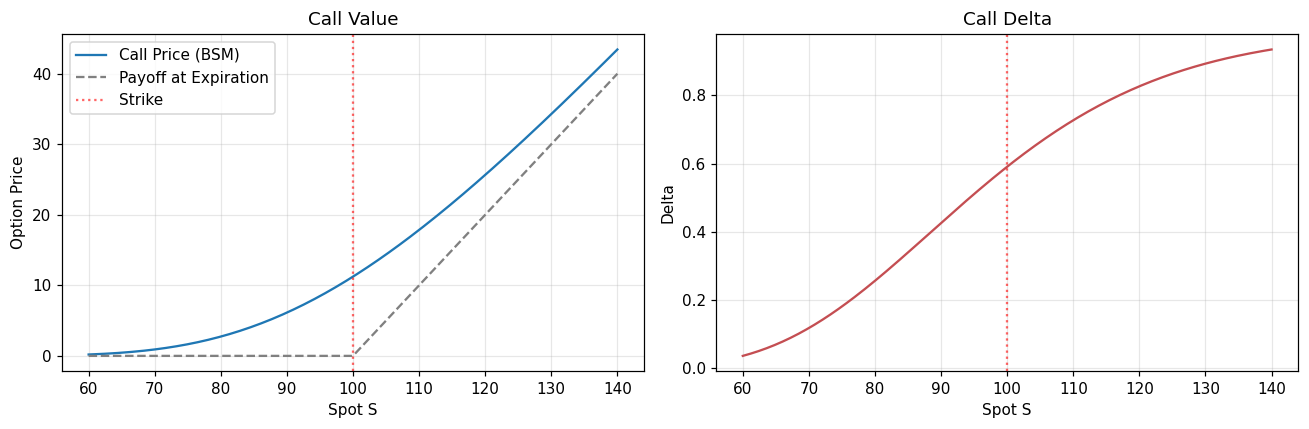

In [36]:
# Call price profile and its Delta by spot price (vectorized)
spots = np.linspace(60, 140, 200)
prices_call = black_scholes_merton(spots, K0, T0, r0, sig0, q0, "call")["price"]
delta_call  = black_scholes_merton(spots, K0, T0, r0, sig0, q0, "call")["delta"]
payoff = np.maximum(spots - K0, 0.0)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(spots, prices_call, label="Call Price (BSM)")
ax[0].plot(spots, payoff, "--", color="gray", label="Payoff at Expiration")
ax[0].axvline(K0, color="red", ls=":", alpha=0.6, label="Strike")
ax[0].set_xlabel("Spot S"); ax[0].set_ylabel("Option Price"); ax[0].set_title("Call Value")
ax[0].legend()
ax[1].plot(spots, delta_call, color="#C44E52")
ax[1].axvline(K0, color="red", ls=":", alpha=0.6)
ax[1].set_xlabel("Spot S"); ax[1].set_ylabel("Delta"); ax[1].set_title("Call Delta")
plt.tight_layout(); plt.show()